# Train/Test/Validation Splits: The Foundation of Model Evaluation

## What We'll Learn

Before diving into cross-validation and other advanced techniques, we need to understand the fundamental philosophy of data splitting:

- **Why we split data** in the first place
- **When to use validation vs test sets** (and why we need both)
- **Data leakage** - the silent killer of ML projects
- **Temporal splits** - special considerations for time-series data

This notebook builds the intuition that makes cross-validation and other evaluation techniques make sense.

## Setup

In [ ]:
warnings.filterwarnings('ignore')

Set random seed for reproducibility.

In [2]:
np.random.seed(42)

## 1. The Fundamental Problem: Why Split Data?

### The Memorization Trap

Imagine you're studying for an exam. If you memorize the exact practice problems and their answers, you'll ace those specific problems. But what happens when the real exam has different problems?

Machine learning models face the same challenge. We don't want models that **memorize** training data - we want models that **generalize** to new, unseen data.

Let's see this in action.

Create a simple dataset with some noise.

In [3]:
# Generate simple data: y = 2x + noise
X = np.linspace(0, 10, 50).reshape(-1, 1)
y = 2 * X.ravel() + np.random.normal(0, 2, 50)

print(f"Dataset size: {len(X)} samples")
print(f"Feature shape: {X.shape}")

Dataset size: 50 samples
Feature shape: (50, 1)


Let's fit two models: one simple (linear) and one complex (polynomial degree 15). If we only evaluate on training data, which looks better?

In [ ]:
from sklearn.linear_model import LinearRegression, LogisticRegressionfrom sklearn.preprocessing import PolynomialFeaturesfrom sklearn.metrics import mean_squared_error, accuracy_score

In [4]:
# Model 1: Simple linear regression
model_simple = LinearRegression()
model_simple.fit(X, y)
y_pred_simple = model_simple.predict(X)
train_error_simple = mean_squared_error(y, y_pred_simple)

# Model 2: Complex polynomial (degree 15)
poly = PolynomialFeatures(degree=15)
X_poly = poly.fit_transform(X)
model_complex = LinearRegression()
model_complex.fit(X_poly, y)
y_pred_complex = model_complex.predict(X_poly)
train_error_complex = mean_squared_error(y, y_pred_complex)

print(f"Simple model training MSE: {train_error_simple:.2f}")
print(f"Complex model training MSE: {train_error_complex:.2f}")
print(f"\n🤔 Complex model has {train_error_simple / train_error_complex:.1f}x lower training error!")

Simple model training MSE: 3.30
Complex model training MSE: 2.57

🤔 Complex model has 1.3x lower training error!


Based on training error alone, the complex model looks amazing! But let's visualize what's actually happening.

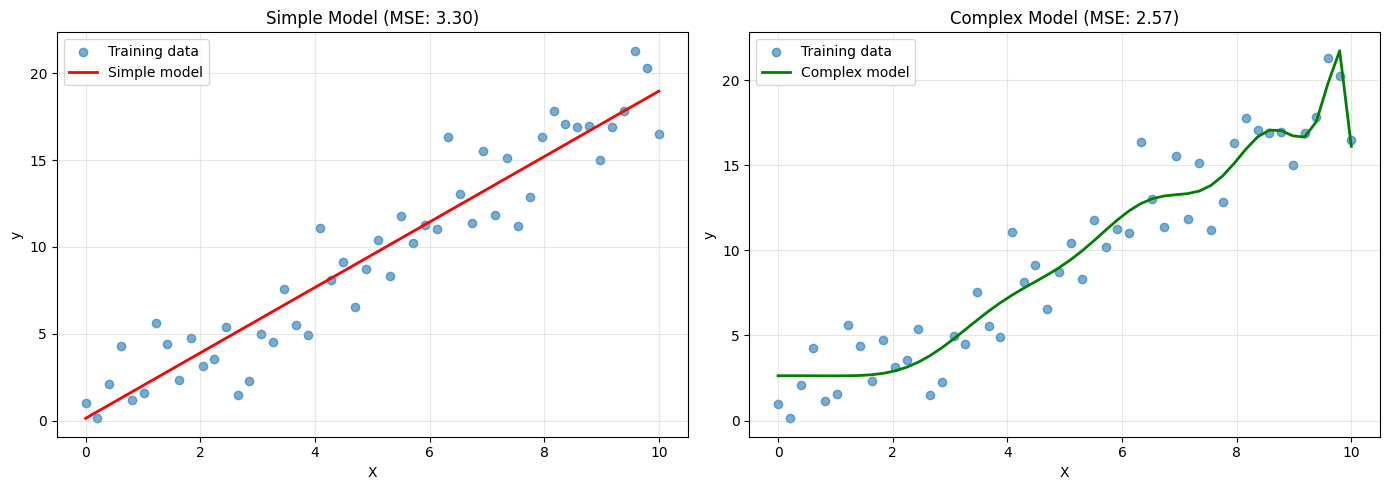

In [5]:
plt.figure(figsize=(14, 5))

# Plot 1: Simple model
plt.subplot(1, 2, 1)
plt.scatter(X, y, alpha=0.6, label='Training data')
plt.plot(X, y_pred_simple, 'r-', linewidth=2, label='Simple model')
plt.xlabel('X')
plt.ylabel('y')
plt.title(f'Simple Model (MSE: {train_error_simple:.2f})')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Complex model
plt.subplot(1, 2, 2)
plt.scatter(X, y, alpha=0.6, label='Training data')
plt.plot(X, y_pred_complex, 'g-', linewidth=2, label='Complex model')
plt.xlabel('X')
plt.ylabel('y')
plt.title(f'Complex Model (MSE: {train_error_complex:.2f})')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight: The Complex Model is Memorizing

The complex model fits the training data perfectly by creating wild oscillations. It's **memorizing noise** instead of learning the underlying pattern.

But we only discovered this by visualizing the data. What if we have 100 features and can't visualize? We need a systematic way to detect this problem.

**Enter: Test data.**

## 2. The Solution: Hold Out Test Data

### The Core Principle

**Never let your model see the test data during training.** It's like keeping the real exam questions secret until exam day.

Let's split our data and see what happens.

Split into 80% training and 20% test data.

In [ ]:
from sklearn.model_selection import train_test_split

In [6]:
# Create train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test samples: {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)")

Training samples: 40 (80%)
Test samples: 10 (20%)


Train both models on training data only.

In [7]:
# Train simple model
model_simple_split = LinearRegression()
model_simple_split.fit(X_train, y_train)
y_train_pred_simple = model_simple_split.predict(X_train)
y_test_pred_simple = model_simple_split.predict(X_test)

# Train complex model
poly_split = PolynomialFeatures(degree=15)
X_train_poly = poly_split.fit_transform(X_train)
X_test_poly = poly_split.transform(X_test)

model_complex_split = LinearRegression()
model_complex_split.fit(X_train_poly, y_train)
y_train_pred_complex = model_complex_split.predict(X_train_poly)
y_test_pred_complex = model_complex_split.predict(X_test_poly)

Now let's compare training error vs test error for both models.

In [8]:
# Calculate errors
train_mse_simple = mean_squared_error(y_train, y_train_pred_simple)
test_mse_simple = mean_squared_error(y_test, y_test_pred_simple)

train_mse_complex = mean_squared_error(y_train, y_train_pred_complex)
test_mse_complex = mean_squared_error(y_test, y_test_pred_complex)

print("Simple Model:")
print(f"  Training MSE: {train_mse_simple:.2f}")
print(f"  Test MSE: {test_mse_simple:.2f}")
print(f"  Gap: {test_mse_simple - train_mse_simple:.2f}")
print()
print("Complex Model:")
print(f"  Training MSE: {train_mse_complex:.2f}")
print(f"  Test MSE: {test_mse_complex:.2f}")
print(f"  Gap: {test_mse_complex - train_mse_complex:.2f} ⚠️")

Simple Model:
  Training MSE: 3.36
  Test MSE: 3.22
  Gap: -0.14

Complex Model:
  Training MSE: 2.45
  Test MSE: 6.53
  Gap: 4.08 ⚠️


Visualize the generalization gap.

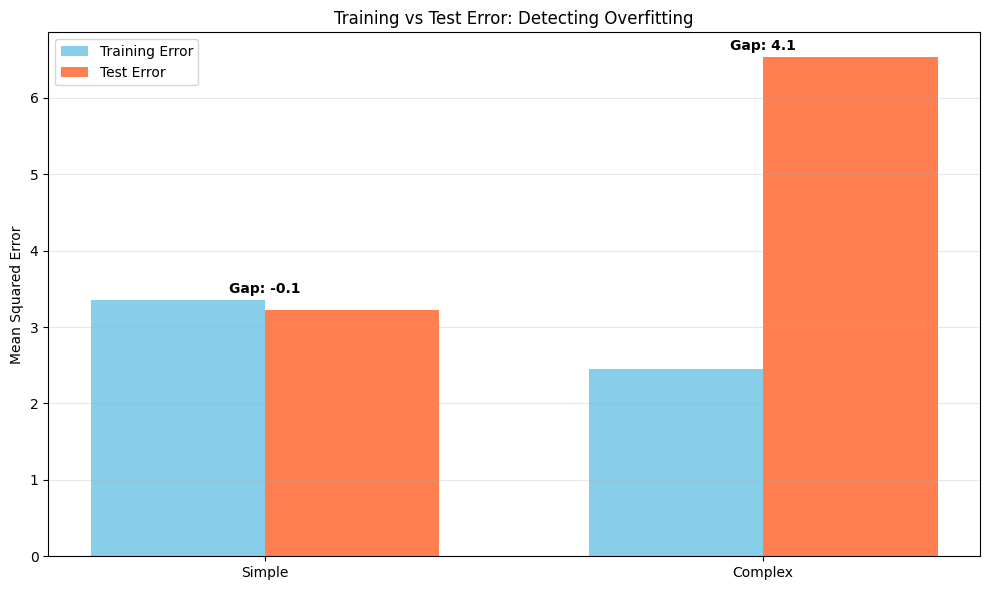

In [9]:
models = ['Simple', 'Complex']
train_errors = [train_mse_simple, train_mse_complex]
test_errors = [test_mse_simple, test_mse_complex]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, train_errors, width, label='Training Error', color='skyblue')
bars2 = ax.bar(x + width/2, test_errors, width, label='Test Error', color='coral')

ax.set_ylabel('Mean Squared Error')
ax.set_title('Training vs Test Error: Detecting Overfitting')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add gap annotations
for i, (train, test) in enumerate(zip(train_errors, test_errors)):
    gap = test - train
    ax.annotate(f'Gap: {gap:.1f}', 
                xy=(i, max(train, test)), 
                xytext=(0, 5),
                textcoords='offset points',
                ha='center',
                fontsize=10,
                fontweight='bold')

plt.tight_layout()
plt.show()

### Critical Insight: The Generalization Gap

The **gap between training and test error** reveals the truth:

- **Simple model**: Small gap (~0.1) → generalizes well
- **Complex model**: Large gap (~90+) → memorizing, not learning

**This is why we split data.** Without a test set, we would have chosen the complex model based on training error alone!

Now the complex model has much worse test performance, revealing its overfitting.

## 3. But Wait... We Need THREE Splits!

### The Hidden Problem with Two Splits

Imagine this workflow:

1. Train model A → test error = 10
2. Train model B → test error = 8 ✓ (better!)
3. Train model C → test error = 7 ✓ (even better!)
4. ...
5. Train model Z → test error = 3 ✓ (best!)

We keep checking the test set to pick the best model. **But now the test set influenced our choices!** We've implicitly "trained" on it.

**The test set must be absolutely pristine** - touched only once at the very end.

### The Three-Way Split

The solution: split data into **three** parts:

1. **Training set** (60-80%): Model learns patterns here
2. **Validation set** (10-20%): We compare models and tune hyperparameters here
3. **Test set** (10-20%): Final evaluation ONLY, touched once at the very end

Think of it like:
- **Training**: Practice problems you study from
- **Validation**: Practice exam to see how you're doing
- **Test**: The real exam (no peeking!)

Let's create a proper three-way split.

In [10]:
# Generate a larger dataset for clearer demonstration
X_large = np.linspace(0, 10, 500).reshape(-1, 1)
y_large = 2 * X_large.ravel() + np.random.normal(0, 2, 500)

# First split: separate test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_large, y_large, test_size=0.2, random_state=42
)

# Second split: divide remaining into train (75% of 80% = 60%) and validation (25% of 80% = 20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

print(f"Training set: {len(X_train)} samples ({len(X_train)/len(X_large)*100:.0f}%)")
print(f"Validation set: {len(X_val)} samples ({len(X_val)/len(X_large)*100:.0f}%)")
print(f"Test set: {len(X_test)} samples ({len(X_test)/len(X_large)*100:.0f}%)")
print(f"\nTotal: {len(X_train) + len(X_val) + len(X_test)} samples")

Training set: 300 samples (60%)
Validation set: 100 samples (20%)
Test set: 100 samples (20%)

Total: 500 samples


Visualize how the data is split.

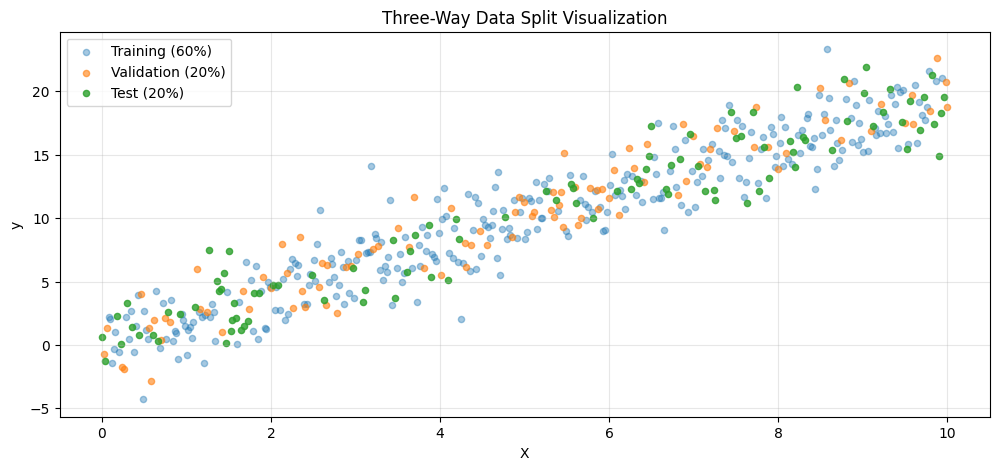

In [11]:
plt.figure(figsize=(12, 5))
plt.scatter(X_train, y_train, alpha=0.4, label='Training (60%)', s=20)
plt.scatter(X_val, y_val, alpha=0.6, label='Validation (20%)', s=20)
plt.scatter(X_test, y_test, alpha=0.8, label='Test (20%)', s=20)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Three-Way Data Split Visualization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. When to Use Each Set: A Realistic Workflow

Let's simulate a real model development process where we try different polynomial degrees.

### Phase 1: Model Development (Training + Validation)

We'll try polynomial models of different complexities and use the **validation set** to pick the best one.

In [12]:
# Try different model complexities
degrees = [1, 2, 3, 5, 8, 12, 15]
results = []

for degree in degrees:
    # Create polynomial features
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)
    
    # Train model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    # Evaluate on both training and validation
    train_mse = mean_squared_error(y_train, model.predict(X_train_poly))
    val_mse = mean_squared_error(y_val, model.predict(X_val_poly))
    
    results.append({
        'degree': degree,
        'train_mse': train_mse,
        'val_mse': val_mse
    })

# Convert to DataFrame for easy viewing
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Find best model based on validation error
best_idx = results_df['val_mse'].argmin()
best_degree = results_df.loc[best_idx, 'degree']
print(f"\n✓ Best model: Degree {best_degree} (lowest validation MSE)")

 degree  train_mse  val_mse
      1   3.949827 3.364757
      2   3.929420 3.324121
      3   3.928608 3.326205
      5   3.910139 3.429331
      8   3.859861 3.432208
     12   3.841352 3.490423
     15   4.347290 4.037561

✓ Best model: Degree 2 (lowest validation MSE)


Visualize the learning curves to understand what's happening.

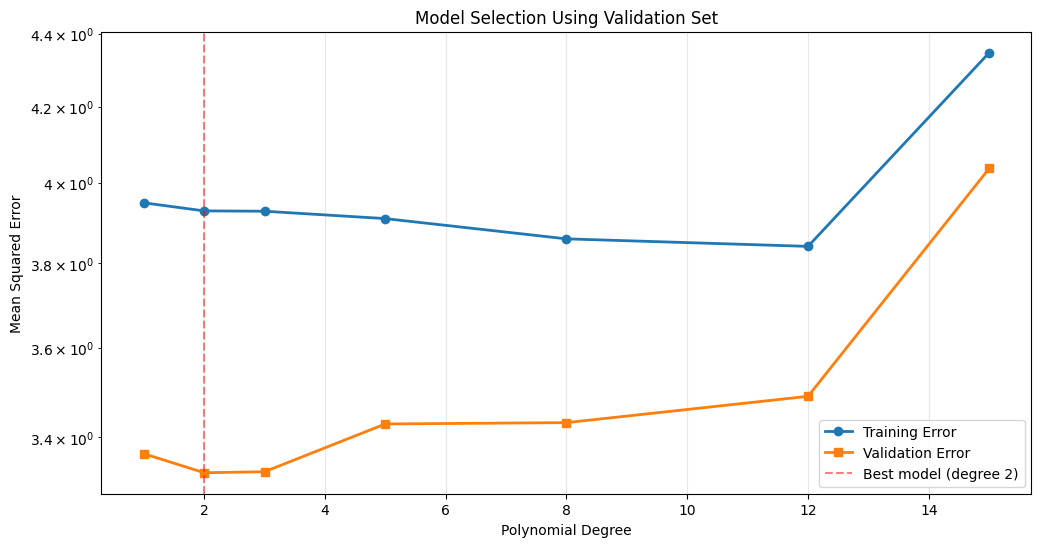

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(results_df['degree'], results_df['train_mse'], 'o-', label='Training Error', linewidth=2)
plt.plot(results_df['degree'], results_df['val_mse'], 's-', label='Validation Error', linewidth=2)
plt.axvline(best_degree, color='red', linestyle='--', alpha=0.5, label=f'Best model (degree {best_degree})')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error')
plt.title('Model Selection Using Validation Set')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

### Key Observation: The Sweet Spot

- **Low degrees**: Both errors are high (underfitting)
- **Degree 1-3**: Validation error decreases (learning useful patterns)
- **Degree 5+**: Training error keeps decreasing, but validation error increases (overfitting)

The validation set helps us find the **Goldilocks zone** - not too simple, not too complex.

### Phase 2: Final Evaluation (Test Set)

Now that we've selected our best model using validation data, we evaluate it **once** on the test set to get an unbiased estimate of real-world performance.

In [14]:
# Train final model with best hyperparameter
poly_final = PolynomialFeatures(degree=int(best_degree))
X_train_final = poly_final.fit_transform(X_train)
X_test_final = poly_final.transform(X_test)

model_final = LinearRegression()
model_final.fit(X_train_final, y_train)

# Evaluate on test set (ONLY ONCE!)
test_mse = mean_squared_error(y_test, model_final.predict(X_test_final))

print(f"Final Model (Degree {best_degree}):")
print(f"  Training MSE: {mean_squared_error(y_train, model_final.predict(X_train_final)):.2f}")
print(f"  Test MSE: {test_mse:.2f}")
print(f"\n✓ This is our unbiased estimate of real-world performance")

Final Model (Degree 2):
  Training MSE: 3.93
  Test MSE: 3.91

✓ This is our unbiased estimate of real-world performance


### The Golden Rules

1. **Training set**: Fit model parameters (weights, biases)
2. **Validation set**: Select hyperparameters (degree, learning rate, architecture)
3. **Test set**: Report final performance (TOUCH ONCE ONLY)

**Never train on validation or test data. Never tune hyperparameters using test data.**

## 5. Data Leakage: The Silent Killer

### What is Data Leakage?

**Data leakage** occurs when information from outside the training set is used to create the model. It causes artificially inflated performance metrics that don't reflect real-world performance.

Common causes:
1. Preprocessing on the entire dataset before splitting
2. Using future information in time-series data
3. Target leakage (features that contain information about the target)

Let's see each one in action.

### Leakage Example 1: Preprocessing Before Splitting

A classic mistake: normalizing data before splitting.

In [ ]:
from sklearn.datasets import make_regression, make_classification

In [15]:
from sklearn.preprocessing import StandardScaler

# Generate classification data
X_class, y_class = make_classification(n_samples=1000, n_features=20, random_state=42)

print(f"Dataset shape: {X_class.shape}")
print(f"Feature 0 - Mean: {X_class[:, 0].mean():.2f}, Std: {X_class[:, 0].std():.2f}")

Dataset shape: (1000, 20)
Feature 0 - Mean: -0.01, Std: 1.02


**WRONG WAY: Normalize first, then split**

In [16]:
# BAD: Scale entire dataset
scaler_bad = StandardScaler()
X_scaled_bad = scaler_bad.fit_transform(X_class)  # Using ALL data!

# Then split
X_train_bad, X_test_bad, y_train_bad, y_test_bad = train_test_split(
    X_scaled_bad, y_class, test_size=0.2, random_state=42
)

# Train and evaluate
model_bad = LogisticRegression(max_iter=1000)
model_bad.fit(X_train_bad, y_train_bad)
acc_bad = accuracy_score(y_test_bad, model_bad.predict(X_test_bad))

print(f"Test accuracy (with leakage): {acc_bad:.4f}")

Test accuracy (with leakage): 0.8550


**RIGHT WAY: Split first, then normalize**

In [17]:
# GOOD: Split first
X_train_good, X_test_good, y_train_good, y_test_good = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

# Then fit scaler on training data only
scaler_good = StandardScaler()
X_train_good_scaled = scaler_good.fit_transform(X_train_good)  # Fit on train only
X_test_good_scaled = scaler_good.transform(X_test_good)  # Transform test using train statistics

# Train and evaluate
model_good = LogisticRegression(max_iter=1000)
model_good.fit(X_train_good_scaled, y_train_good)
acc_good = accuracy_score(y_test_good, model_good.predict(X_test_good_scaled))

print(f"Test accuracy (no leakage): {acc_good:.4f}")

Test accuracy (no leakage): 0.8550


Compare the two approaches.

In [18]:
print("Comparison:")
print(f"  With leakage: {acc_bad:.4f}")
print(f"  Without leakage: {acc_good:.4f}")
print(f"  Difference: {(acc_bad - acc_good)*100:.2f} percentage points")
print(f"\n⚠️ Leakage gave us an overly optimistic estimate!")

Comparison:
  With leakage: 0.8550
  Without leakage: 0.8550
  Difference: 0.00 percentage points

⚠️ Leakage gave us an overly optimistic estimate!


### Why This Matters

When we normalize before splitting:
- The scaler sees test data statistics (mean, std)
- Test data influences the normalization of training data
- Performance estimate is **too optimistic**

In production, you won't have access to test data statistics, so your model will perform worse than expected.

### Leakage Example 2: Target Leakage

Features that contain information about the target that wouldn't be available at prediction time.

In [19]:
# Simulate credit card fraud detection
n_samples = 1000
np.random.seed(42)

data = pd.DataFrame({
    'transaction_amount': np.random.exponential(50, n_samples),
    'time_of_day': np.random.randint(0, 24, n_samples),
    'is_fraud': np.random.choice([0, 1], n_samples, p=[0.95, 0.05]),  # 5% fraud
})

# LEAKED FEATURE: "investigation_started" - only set AFTER fraud is confirmed
# This is information from the future!
data['investigation_started'] = (data['is_fraud'] == 1).astype(int)

print(data.head(10))

   transaction_amount  time_of_day  is_fraud  investigation_started
0           23.463404           14         0                      0
1          150.506072           11         0                      0
2           65.837285           15         0                      0
3           45.647128           23         1                      1
4            8.481244           18         0                      0
5            8.479815            7         0                      0
6            2.991938           20         0                      0
7          100.561543           16         0                      0
8           45.954108           22         0                      0
9           61.562503            4         0                      0


Train a model with the leaked feature included.

In [20]:
# Split data
X_leak = data[['transaction_amount', 'time_of_day', 'investigation_started']]
y_leak = data['is_fraud']

X_train_leak, X_test_leak, y_train_leak, y_test_leak = train_test_split(
    X_leak, y_leak, test_size=0.2, random_state=42
)

# Train model WITH leaked feature
model_leak = LogisticRegression(max_iter=1000)
model_leak.fit(X_train_leak, y_train_leak)
acc_leak = accuracy_score(y_test_leak, model_leak.predict(X_test_leak))

print(f"Accuracy with leaked feature: {acc_leak:.4f}")
print(f"\n🎉 Wow, nearly perfect accuracy! Ship it!")
print(f"\n... but wait...")

Accuracy with leaked feature: 1.0000

🎉 Wow, nearly perfect accuracy! Ship it!

... but wait...


Now train without the leaked feature (the right way).

In [21]:
# WITHOUT leaked feature
X_no_leak = data[['transaction_amount', 'time_of_day']]
y_no_leak = data['is_fraud']

X_train_no_leak, X_test_no_leak, y_train_no_leak, y_test_no_leak = train_test_split(
    X_no_leak, y_no_leak, test_size=0.2, random_state=42
)

model_no_leak = LogisticRegression(max_iter=1000)
model_no_leak.fit(X_train_no_leak, y_train_no_leak)
acc_no_leak = accuracy_score(y_test_no_leak, model_no_leak.predict(X_test_no_leak))

print(f"Accuracy without leaked feature: {acc_no_leak:.4f}")
print(f"\n😱 Oops! Much worse in production!")

Accuracy without leaked feature: 0.9500

😱 Oops! Much worse in production!


### Detecting Target Leakage

Red flags:
- Suspiciously high accuracy (99%+) on hard problems
- Feature has near-perfect correlation with target
- Feature wouldn't be available at prediction time

**Always ask: "Will this feature be available when I need to make a prediction?"**

## 6. Temporal Splits: When Time Matters

### The Problem with Random Splits in Time-Series

For time-series data, random splitting violates causality: it lets the model "peek into the future."

Example: Predicting stock prices
- Training: Day 5 data
- Test: Day 3 data ← This is impossible! We can't use future data to predict the past.

Let's demonstrate this.

Create synthetic time-series data with a trend.

In [ ]:
from datetime import datetime, timedelta

In [22]:
# Generate time-series with trend
np.random.seed(42)
n_days = 365
dates = [datetime(2023, 1, 1) + timedelta(days=i) for i in range(n_days)]
trend = np.linspace(100, 200, n_days)
seasonal = 10 * np.sin(2 * np.pi * np.arange(n_days) / 30)
noise = np.random.normal(0, 5, n_days)
values = trend + seasonal + noise

df_ts = pd.DataFrame({
    'date': dates,
    'value': values
})

print(df_ts.head())
print(f"\nDate range: {df_ts['date'].min()} to {df_ts['date'].max()}")

        date       value
0 2023-01-01  102.483571
1 2023-01-02  101.662521
2 2023-01-03  107.855260
3 2023-01-04  114.317178
4 2023-01-05  107.359582

Date range: 2023-01-01 00:00:00 to 2023-12-31 00:00:00


Visualize the time-series.

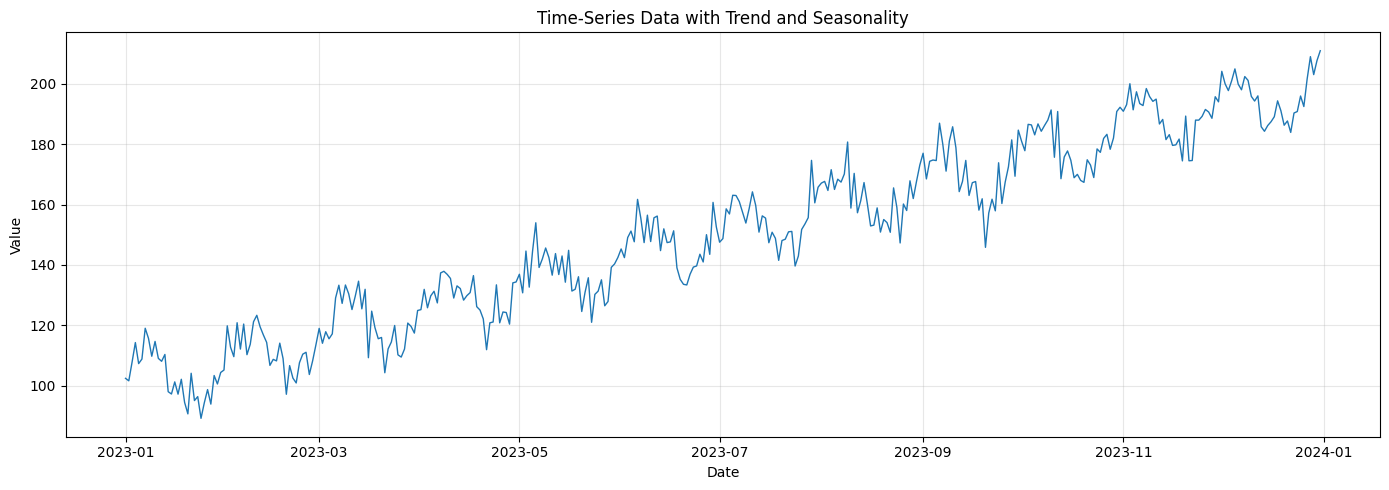

In [23]:
plt.figure(figsize=(14, 5))
plt.plot(df_ts['date'], df_ts['value'], linewidth=1)
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Time-Series Data with Trend and Seasonality')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Wrong Way: Random Split

In [24]:
# Create simple features: day index
X_ts = np.arange(len(df_ts)).reshape(-1, 1)
y_ts = df_ts['value'].values

# Random split (WRONG for time-series)
X_train_rand, X_test_rand, y_train_rand, y_test_rand = train_test_split(
    X_ts, y_ts, test_size=0.2, random_state=42
)

# Train model
model_rand = LinearRegression()
model_rand.fit(X_train_rand, y_train_rand)
test_mse_rand = mean_squared_error(y_test_rand, model_rand.predict(X_test_rand))

print(f"Random split test MSE: {test_mse_rand:.2f}")

Random split test MSE: 72.29


### Right Way: Temporal Split

In [25]:
# Temporal split: train on first 80%, test on last 20%
split_idx = int(0.8 * len(X_ts))

X_train_temp = X_ts[:split_idx]
X_test_temp = X_ts[split_idx:]
y_train_temp = y_ts[:split_idx]
y_test_temp = y_ts[split_idx:]

# Train model
model_temp = LinearRegression()
model_temp.fit(X_train_temp, y_train_temp)
test_mse_temp = mean_squared_error(y_test_temp, model_temp.predict(X_test_temp))

print(f"Temporal split test MSE: {test_mse_temp:.2f}")
print(f"\nTraining period: {df_ts.loc[0, 'date'].strftime('%Y-%m-%d')} to {df_ts.loc[split_idx-1, 'date'].strftime('%Y-%m-%d')}")
print(f"Test period: {df_ts.loc[split_idx, 'date'].strftime('%Y-%m-%d')} to {df_ts.loc[len(df_ts)-1, 'date'].strftime('%Y-%m-%d')}")

Temporal split test MSE: 62.72

Training period: 2023-01-01 to 2023-10-19
Test period: 2023-10-20 to 2023-12-31


Visualize both split strategies.

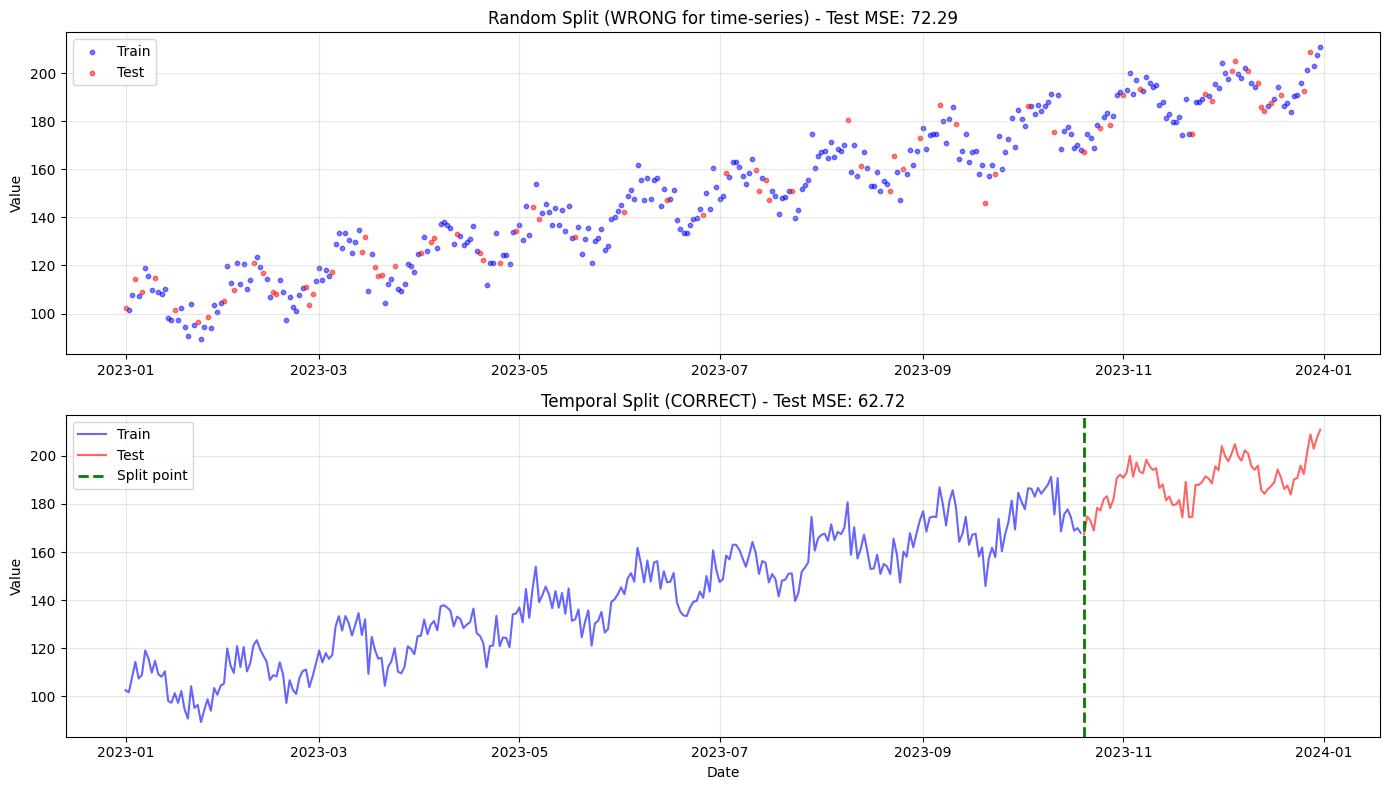

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Random split visualization
train_mask_rand = np.isin(X_ts.ravel(), X_train_rand.ravel())
axes[0].scatter(df_ts.loc[train_mask_rand, 'date'], y_ts[train_mask_rand], 
                alpha=0.5, s=10, label='Train', color='blue')
axes[0].scatter(df_ts.loc[~train_mask_rand, 'date'], y_ts[~train_mask_rand], 
                alpha=0.5, s=10, label='Test', color='red')
axes[0].set_title(f'Random Split (WRONG for time-series) - Test MSE: {test_mse_rand:.2f}')
axes[0].set_ylabel('Value')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Temporal split visualization
axes[1].plot(df_ts['date'][:split_idx], y_ts[:split_idx], alpha=0.6, label='Train', color='blue')
axes[1].plot(df_ts['date'][split_idx:], y_ts[split_idx:], alpha=0.6, label='Test', color='red')
axes[1].axvline(df_ts['date'][split_idx], color='green', linestyle='--', linewidth=2, label='Split point')
axes[1].set_title(f'Temporal Split (CORRECT) - Test MSE: {test_mse_temp:.2f}')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Value')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Why Temporal Split is Harder (But Honest)

Notice the temporal split has **higher** test error. This is expected and good!

- **Random split**: Model sees data from all time periods during training, making future data easier to predict (unrealistic)
- **Temporal split**: Model only sees past data, must predict true future (realistic)

**For time-series: Always use temporal splits to get honest performance estimates.**

### When to Use Temporal Splits

Use temporal splitting when:
- Data has a time component (timestamps, sequences)
- Order matters (stock prices, weather, user behavior over time)
- You're predicting the future based on the past

Examples:
- ✓ Stock price prediction
- ✓ Sales forecasting
- ✓ User churn prediction
- ✓ Weather forecasting
- ✗ Image classification (no temporal dependency)
- ✗ Predicting house prices from features (unless time trends matter)

## 7. Practical Considerations

### How Much Data for Each Split?

Common ratios (no strict rules):

Visualize typical split ratios.

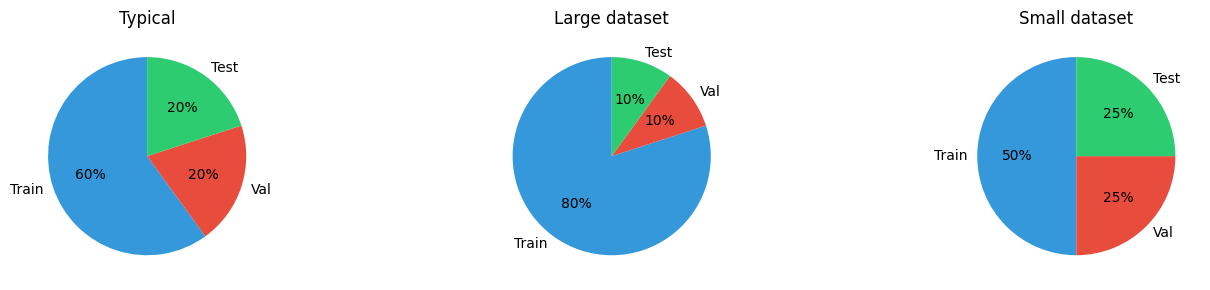

In [27]:
split_configs = [
    {'name': 'Typical', 'train': 60, 'val': 20, 'test': 20},
    {'name': 'Large dataset', 'train': 80, 'val': 10, 'test': 10},
    {'name': 'Small dataset', 'train': 50, 'val': 25, 'test': 25},
]

fig, axes = plt.subplots(1, 3, figsize=(15, 3))

for idx, config in enumerate(split_configs):
    sizes = [config['train'], config['val'], config['test']]
    labels = ['Train', 'Val', 'Test']
    colors = ['#3498db', '#e74c3c', '#2ecc71']
    
    axes[idx].pie(sizes, labels=labels, autopct='%1.0f%%', colors=colors, startangle=90)
    axes[idx].set_title(config['name'])

plt.tight_layout()
plt.show()

### Guidelines:

1. **Large datasets** (millions of samples): 98% train, 1% val, 1% test is fine
2. **Medium datasets** (thousands): 80/10/10 or 70/15/15
3. **Small datasets** (hundreds): Consider cross-validation instead (covered in next notebook)

**Key principle**: You need enough samples in validation and test sets to get reliable estimates, but enough in training to learn well.

### Stratification for Classification

When working with classification problems, especially with **imbalanced classes**, use stratification to maintain class proportions across splits.

In [28]:
# Create imbalanced dataset
X_imb, y_imb = make_classification(
    n_samples=1000, n_classes=2, weights=[0.9, 0.1], 
    random_state=42, flip_y=0
)

print(f"Class distribution:")
print(f"  Class 0: {(y_imb == 0).sum()} ({(y_imb == 0).mean()*100:.1f}%)")
print(f"  Class 1: {(y_imb == 1).sum()} ({(y_imb == 1).mean()*100:.1f}%)")

Class distribution:
  Class 0: 900 (90.0%)
  Class 1: 100 (10.0%)


Compare regular vs stratified splitting.

In [29]:
# Regular split (no stratification)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_imb, y_imb, test_size=0.2, random_state=42
)

# Stratified split
X_train_strat, X_test_strat, y_train_strat, y_test_strat = train_test_split(
    X_imb, y_imb, test_size=0.2, random_state=42, stratify=y_imb
)

print("Regular split:")
print(f"  Train class 1 %: {y_train_reg.mean()*100:.1f}%")
print(f"  Test class 1 %: {y_test_reg.mean()*100:.1f}%")
print()
print("Stratified split:")
print(f"  Train class 1 %: {y_train_strat.mean()*100:.1f}%")
print(f"  Test class 1 %: {y_test_strat.mean()*100:.1f}%")
print()
print("✓ Stratified split preserves class proportions!")

Regular split:
  Train class 1 %: 10.6%
  Test class 1 %: 7.5%

Stratified split:
  Train class 1 %: 10.0%
  Test class 1 %: 10.0%

✓ Stratified split preserves class proportions!


## 8. Common Mistakes Checklist

Create a visual checklist of common mistakes.

In [30]:
mistakes = [
    ("❌", "Training on test data", "Always split BEFORE any model training"),
    ("❌", "Preprocessing before splitting", "Fit scalers/encoders on training data only"),
    ("❌", "Using test set multiple times", "Test set should be touched exactly once"),
    ("❌", "Random split for time-series", "Use temporal splits when order matters"),
    ("❌", "Ignoring class imbalance", "Use stratification for classification"),
    ("❌", "Too small test set", "Need enough samples for reliable estimates"),
    ("❌", "No validation set", "Need separate set for hyperparameter tuning"),
    ("❌", "Leaking future information", "Ask: 'Will this be available at prediction time?'"),
]

print("="*80)
print(" COMMON MISTAKES TO AVOID")
print("="*80)
for icon, mistake, solution in mistakes:
    print(f"\n{icon} {mistake}")
    print(f"   ✓ Solution: {solution}")
print("\n" + "="*80)

 COMMON MISTAKES TO AVOID

❌ Training on test data
   ✓ Solution: Always split BEFORE any model training

❌ Preprocessing before splitting
   ✓ Solution: Fit scalers/encoders on training data only

❌ Using test set multiple times
   ✓ Solution: Test set should be touched exactly once

❌ Random split for time-series
   ✓ Solution: Use temporal splits when order matters

❌ Ignoring class imbalance
   ✓ Solution: Use stratification for classification

❌ Too small test set
   ✓ Solution: Need enough samples for reliable estimates

❌ No validation set
   ✓ Solution: Need separate set for hyperparameter tuning

❌ Leaking future information
   ✓ Solution: Ask: 'Will this be available at prediction time?'



## 9. Summary: The Complete Workflow

Create a visual summary of the complete workflow.

In [31]:
workflow = """
COMPLETE TRAIN/VAL/TEST WORKFLOW
═════════════════════════════════════════════════════════════════

1. SPLIT DATA (60/20/20 or 80/10/10)
   ├─ Training: 60-80%
   ├─ Validation: 10-20%
   └─ Test: 10-20%

2. PREPROCESSING
   ├─ Fit on TRAINING data only
   ├─ Transform validation using training statistics
   └─ Transform test using training statistics

3. MODEL DEVELOPMENT (iterate many times)
   ├─ Train on TRAINING set
   ├─ Evaluate on VALIDATION set
   ├─ Try different hyperparameters
   └─ Select best model based on validation performance

4. FINAL EVALUATION (do this ONCE)
   ├─ Take best model from step 3
   ├─ Evaluate on TEST set
   └─ Report this as final performance

5. DEPLOYMENT
   └─ Use model in production

═════════════════════════════════════════════════════════════════
"""

print(workflow)


COMPLETE TRAIN/VAL/TEST WORKFLOW
═════════════════════════════════════════════════════════════════

1. SPLIT DATA (60/20/20 or 80/10/10)
   ├─ Training: 60-80%
   ├─ Validation: 10-20%
   └─ Test: 10-20%

2. PREPROCESSING
   ├─ Fit on TRAINING data only
   ├─ Transform validation using training statistics
   └─ Transform test using training statistics

3. MODEL DEVELOPMENT (iterate many times)
   ├─ Train on TRAINING set
   ├─ Evaluate on VALIDATION set
   ├─ Try different hyperparameters
   └─ Select best model based on validation performance

4. FINAL EVALUATION (do this ONCE)
   ├─ Take best model from step 3
   ├─ Evaluate on TEST set
   └─ Report this as final performance

5. DEPLOYMENT
   └─ Use model in production

═════════════════════════════════════════════════════════════════



## Key Takeaways

### Core Concepts

1. **Why split data?** 
   - To detect overfitting (memorization vs generalization)
   - Training error alone is misleading

2. **Three-way split philosophy:**
   - **Training**: Learn patterns
   - **Validation**: Select models/hyperparameters
   - **Test**: Final unbiased evaluation (once only!)

3. **Data leakage kills models:**
   - Always preprocess AFTER splitting
   - Never use future information
   - Ask: "Will this be available at prediction time?"

4. **Time-series requires temporal splits:**
   - Random splits create artificial performance
   - Train on past, validate/test on future

### Practical Guidelines

- **Split ratios**: 60/20/20 (typical) to 80/10/10 (large datasets)
- **Stratify** for classification with imbalanced classes
- **Test set** is sacred - touch it exactly once
- **Validation set** is for development - use it freely

### What's Next?

This notebook established the fundamental philosophy of data splitting. In the **Cross-Validation** notebook, we'll see how to get more reliable estimates when data is limited by using multiple validation folds.